In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv("../data/processed/dk2_merged_price_weather_energy.csv")

df["HourUTC"] = pd.to_datetime(df["HourUTC"])
df["HourDK"] = pd.to_datetime(df["HourDK"])

df = df.sort_values("HourUTC").reset_index(drop=True)

df.head()

,HourUTC,HourDK,PriceArea,SpotPriceEUR,hour,day_of_week,month,year,is_weekend,price_lag_24h,...,offshore_wind_mwh,onshore_wind_mwh,solar_mwh,total_wind_mwh,renewable_generation_mwh,net_load_mwh,ExchangeSE_MWh,ExchangeGE_MWh,ExchangeGreatBelt_MWh,PowerToHeatMWh
0,2024-01-07 23:00:00,2024-01-08 00:00:00,DK2,87.019997,0,0,1,2024,0,86.150002,...,791.7307,300.389069,0.057306,1092.119769,1092.177075,791.314215,528.98475,73.031,-494.5,69.490823
1,2024-01-08 00:00:00,2024-01-08 01:00:00,DK2,84.320000,1,0,1,2024,0,82.459999,...,816.1792,326.746273,0.063193,1142.925473,1142.988666,727.853534,352.17200,201.702,-504.2,63.681755
2,2024-01-08 01:00:00,2024-01-08 02:00:00,DK2,81.820000,2,0,1,2024,0,79.220001,...,811.9769,313.381953,0.052199,1125.358853,1125.411052,707.195154,183.17925,419.060,-570.6,62.729644
3,2024-01-08 02:00:00,2024-01-08 03:00:00,DK2,79.110001,3,0,1,2024,0,77.529999,...,802.1109,273.226503,0.054638,1075.337403,1075.392041,738.309639,-18.11300,300.730,-221.5,61.851473
4,2024-01-08 03:00:00,2024-01-08 04:00:00,DK2,78.480003,4,0,1,2024,0,76.889999,...,789.7893,262.512406,0.060724,1052.301706,1052.362430,742.929387,-313.90875,438.479,-57.0,64.752116


In [3]:
df["target_24h_ahead"] = df["SpotPriceEUR"].shift(-24)

In [4]:
df_24h = df.dropna(subset=["target_24h_ahead"]).reset_index(drop=True)

print("Rows:", len(df_24h))
print("Date range:", df_24h["HourUTC"].min(), "→", df_24h["HourUTC"].max())

Rows: 9791
Date range: 2024-01-07 23:00:00 → 2025-02-18 21:00:00


In [5]:
df_24h["pred_baseline_current_price"] = df_24h["SpotPriceEUR"]

In [6]:
df_24h["pred_baseline_rolling_24h"] = df_24h["price_rolling_mean_24h"]
df_24h["pred_baseline_rolling_168h"] = df_24h["price_rolling_mean_168h"]

In [7]:
target_col = "target_24h_ahead"

exclude_cols = [
    "HourUTC",
    "HourDK",
    "PriceArea",
    "target_next_hour",
    "target_24h_ahead",
    "pred_baseline_current_price",
    "pred_baseline_rolling_24h",
    "pred_baseline_rolling_168h",
]

feature_cols = [col for col in df_24h.columns if col not in exclude_cols]

X = df_24h[feature_cols].select_dtypes(include=["number"])
y = df_24h[target_col]

feature_cols = X.columns.tolist()

feature_cols

['SpotPriceEUR',
 'hour',
 'day_of_week',
 'month',
 'year',
 'is_weekend',
 'price_lag_24h',
 'price_lag_48h',
 'price_lag_168h',
 'price_rolling_mean_24h',
 'price_rolling_std_24h',
 'price_rolling_mean_168h',
 'price_rolling_std_168h',
 'temperature_2m',
 'wind_speed_10m',
 'wind_speed_100m',
 'cloud_cover',
 'shortwave_radiation',
 'GrossConsumptionMWh',
 'CentralPowerMWh',
 'LocalPowerMWh',
 'CommercialPowerMWh',
 'offshore_wind_mwh',
 'onshore_wind_mwh',
 'solar_mwh',
 'total_wind_mwh',
 'renewable_generation_mwh',
 'net_load_mwh',
 'ExchangeSE_MWh',
 'ExchangeGE_MWh',
 'ExchangeGreatBelt_MWh',
 'PowerToHeatMWh']

In [8]:
split_date = "2024-11-01"

train = df_24h[df_24h["HourUTC"] < split_date].copy()
test = df_24h[df_24h["HourUTC"] >= split_date].copy()

X_train = train[feature_cols]
y_train = train[target_col]

X_test = test[feature_cols]
y_test = test[target_col]

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("Train range:", train["HourUTC"].min(), "→", train["HourUTC"].max())
print("Test range:", test["HourUTC"].min(), "→", test["HourUTC"].max())

Train: (7153, 32)
Test: (2638, 32)
Train range: 2024-01-07 23:00:00 → 2024-10-31 23:00:00
Test range: 2024-11-01 00:00:00 → 2025-02-18 21:00:00


In [9]:
xgb_24h = XGBRegressor(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_24h.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [10]:
test["pred_xgboost_24h"] = xgb_24h.predict(X_test)

In [11]:
def evaluate_forecast(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    return {
        "model": model_name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
    }

In [12]:
results = []

results.append(evaluate_forecast(
    test["target_24h_ahead"],
    test["pred_baseline_current_price"],
    "Current price baseline 24h"
))

results.append(evaluate_forecast(
    test["target_24h_ahead"],
    test["pred_baseline_rolling_24h"],
    "Rolling mean 24h baseline"
))

results.append(evaluate_forecast(
    test["target_24h_ahead"],
    test["pred_baseline_rolling_168h"],
    "Rolling mean 168h baseline"
))

results.append(evaluate_forecast(
    test["target_24h_ahead"],
    test["pred_xgboost_24h"],
    "XGBoost 24h"
))

results_24h = pd.DataFrame(results).sort_values("MAE").reset_index(drop=True)
results_24h

,model,MAE,RMSE
0,Current price baseline 24h,43.11,67.25
1,XGBoost 24h,43.59,66.79
2,Rolling mean 24h baseline,50.70,76.07
3,Rolling mean 168h baseline,52.87,77.20


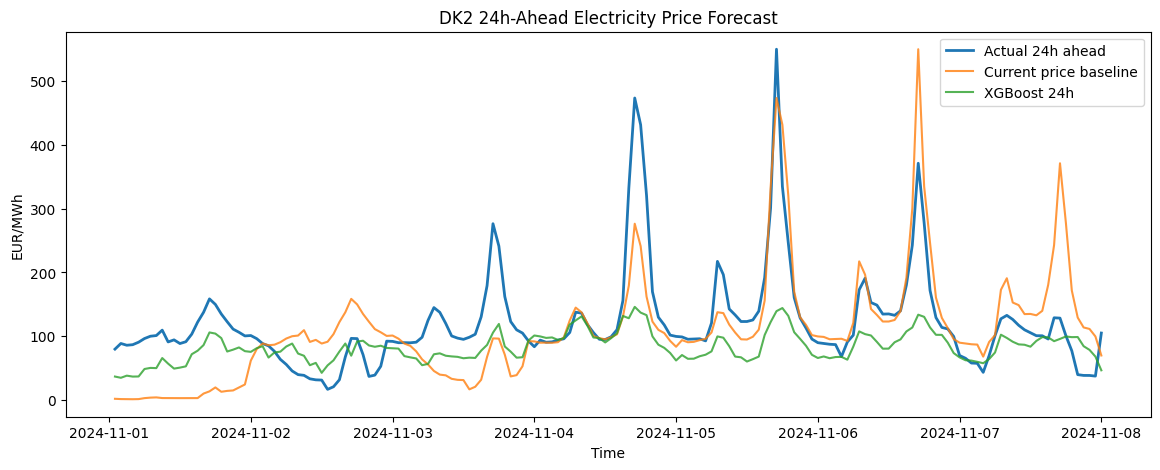

In [13]:
sample = test.head(168)

plt.figure(figsize=(14, 5))

plt.plot(
    sample["HourDK"],
    sample["target_24h_ahead"],
    label="Actual 24h ahead",
    linewidth=2
)

plt.plot(
    sample["HourDK"],
    sample["pred_baseline_current_price"],
    label="Current price baseline",
    alpha=0.8
)

plt.plot(
    sample["HourDK"],
    sample["pred_xgboost_24h"],
    label="XGBoost 24h",
    alpha=0.8
)

plt.title("DK2 24h-Ahead Electricity Price Forecast")
plt.xlabel("Time")
plt.ylabel("EUR/MWh")
plt.legend()
plt.show()

In [14]:
importance_24h = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb_24h.feature_importances_
}).sort_values("importance", ascending=False)

importance_24h.head(20)

,feature,importance
0,SpotPriceEUR,0.200488
1,hour,0.100872
17,shortwave_radiation,0.085882
24,solar_mwh,0.053799
2,day_of_week,0.050149
7,price_lag_48h,0.048259
23,onshore_wind_mwh,0.025430
8,price_lag_168h,0.023741
22,offshore_wind_mwh,0.023396
25,total_wind_mwh,0.022986


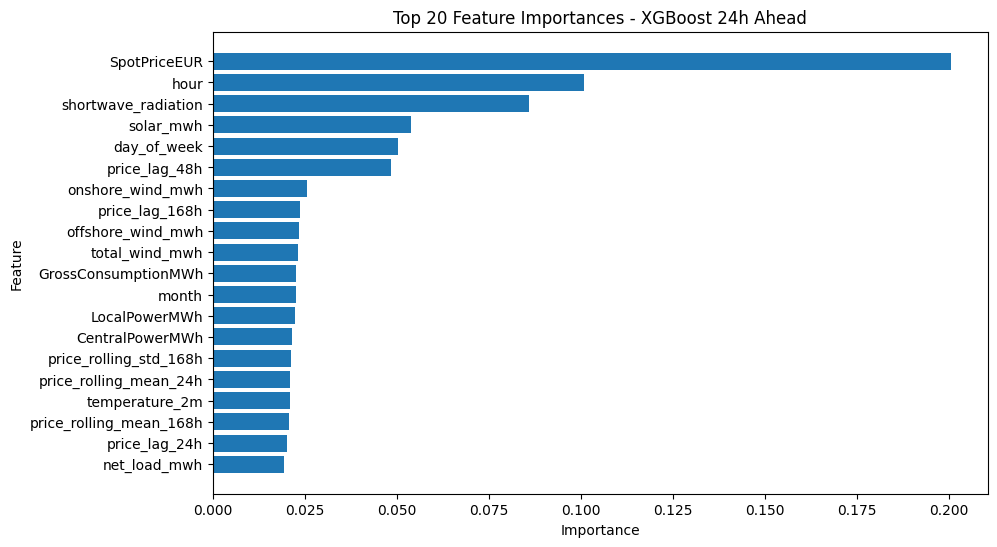

In [15]:
top_importance = importance_24h.head(20)

plt.figure(figsize=(10, 6))
plt.barh(top_importance["feature"][::-1], top_importance["importance"][::-1])
plt.title("Top 20 Feature Importances - XGBoost 24h Ahead")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [16]:
from pathlib import Path

reports_dir = Path("../reports")
reports_dir.mkdir(parents=True, exist_ok=True)

results_24h.to_csv("../reports/model_comparison_24h_DK2.csv", index=False)
importance_24h.to_csv("../reports/xgboost_24h_feature_importance_DK2.csv", index=False)

## Conclusion

This notebook extends the forecasting problem from next-hour prediction to 24-hour-ahead prediction.

The XGBoost model achieved a MAE of 43.59 EUR/MWh and RMSE of 66.79 EUR/MWh. The strongest baseline by MAE was the current price baseline with MAE 43.11 EUR/MWh, while XGBoost slightly improved RMSE.

This suggests that the model is not yet clearly outperforming a strong naive baseline in average error, but it may reduce larger errors. Feature importance shows that current price, hour of day, solar radiation, solar generation, wind generation and consumption-related features are relevant explanatory variables.

The next step is to improve the forecasting setup by tuning the model, testing additional horizons, and evaluating whether future-known variables such as weather forecasts can improve performance.

In [17]:
baseline_mae = results_24h.loc[
    results_24h["model"] == "Current price baseline 24h", "MAE"
].values[0]

xgb_mae = results_24h.loc[
    results_24h["model"] == "XGBoost 24h", "MAE"
].values[0]

mae_improvement = (baseline_mae - xgb_mae) / baseline_mae * 100

print(f"MAE improvement vs current price baseline: {mae_improvement:.2f}%")

MAE improvement vs current price baseline: -1.11%
